In [1]:

import sklearn
print(sklearn.__version__)

1.9.0


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load trained models
driver_safety_model = joblib.load("../MODELS/driver_safety_model.pkl")
breakdown_model = joblib.load("../MODELS/breakdown_model.pkl")


In [3]:
df=pd.read_csv("../DATA/processed/truck_processed.csv")
df.shape

(5000, 19)

In [4]:
from sklearn.model_selection import train_test_split

# Driver Safety
X_driver = df.drop(columns=["Driver_Risk", "Breakdown_Risk"])
y_driver = df["Driver_Risk"]

X_driver_train, X_driver_test, y_driver_train, y_driver_test = train_test_split(
    X_driver,
    y_driver,
    test_size=0.20,
    random_state=42,
    stratify=y_driver
)

# Breakdown
X_breakdown = df.drop(columns=["Driver_Risk", "Breakdown_Risk"])
y_breakdown = df["Breakdown_Risk"]

X_breakdown_train, X_breakdown_test, y_breakdown_train, y_breakdown_test = train_test_split(
    X_breakdown,
    y_breakdown,
    test_size=0.20,
    random_state=42,
    stratify=y_breakdown
)

print("Driver Safety Train:", X_driver_train.shape)
print("Driver Safety Test:", X_driver_test.shape)

print("Breakdown Train:", X_breakdown_train.shape)
print("Breakdown Test:", X_breakdown_test.shape)

Driver Safety Train: (4000, 17)
Driver Safety Test: (1000, 17)
Breakdown Train: (4000, 17)
Breakdown Test: (1000, 17)


In [5]:
driver_pred = driver_safety_model.predict(X_driver_test)

driver_probability = driver_safety_model.predict_proba(X_driver_test)[:, 1]

print("First 10 Predictions:", driver_pred[:10])
print("First 10 Probabilities:", driver_probability[:10])

First 10 Predictions: [0 1 0 0 1 1 1 1 0 1]
First 10 Probabilities: [0.09  1.    0.    0.    0.96  0.985 1.    0.99  0.065 1.   ]


In [6]:
breakdown_pred=breakdown_model.predict(X_breakdown_test)
breakdown_probability=breakdown_model.predict_proba(X_breakdown_test)[:, 1]

print("first 10 predication:",breakdown_pred[:10])
print("first 10 probabilities:",breakdown_probability[:10])


first 10 predication: [0 0 0 1 0 0 0 0 0 0]
first 10 probabilities: [0.005 0.    0.005 0.735 0.12  0.    0.11  0.    0.01  0.05 ]


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay    

driver_accuracy = accuracy_score(y_driver_test, driver_pred)
driver_precision = precision_score(y_driver_test, driver_pred)
driver_recall = recall_score(y_driver_test, driver_pred)
driver_f1 = f1_score(y_driver_test, driver_pred)

print("Driver Safety Model Evaluation")

print("Accuracy :", round(driver_accuracy, 4))
print("Precision:", round(driver_precision, 4))
print("Recall   :", round(driver_recall, 4))
print("F1 Score :", round(driver_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_driver_test,
    driver_pred,
    target_names=["Low Risk", "High Risk"]
))

Driver Safety Model Evaluation
Accuracy : 0.988
Precision: 1.0
Recall   : 0.9703
F1 Score : 0.9849

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.98      1.00      0.99       596
   High Risk       1.00      0.97      0.98       404

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [8]:
breakdown_accuracy = accuracy_score(y_breakdown_test, breakdown_pred)
breakdown_precision = precision_score(y_breakdown_test, breakdown_pred)
breakdown_recall = recall_score(y_breakdown_test, breakdown_pred)
breakdown_f1 = f1_score(y_breakdown_test, breakdown_pred)

print("Breakdown Model Evaluation")
print("Accuracy :", round(breakdown_accuracy, 4))
print("Precision:", round(breakdown_precision, 4))      
print("Recall   :", round(breakdown_recall, 4))
print("F1 score:",round(breakdown_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_breakdown_test,
    breakdown_pred,
    target_names=["Low Risk", "High Risk"]
))

Breakdown Model Evaluation
Accuracy : 0.98
Precision: 0.9643
Recall   : 0.75
F1 score: 0.8438

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.98      1.00      0.99       928
   High Risk       0.96      0.75      0.84        72

    accuracy                           0.98      1000
   macro avg       0.97      0.87      0.92      1000
weighted avg       0.98      0.98      0.98      1000



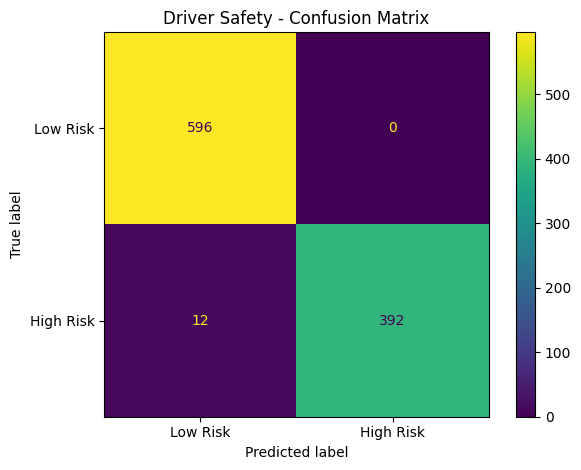

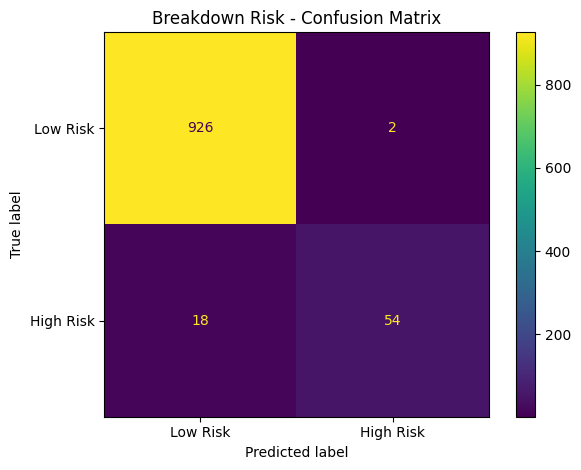

In [10]:
import matplotlib.pyplot as plt

driver_cm = confusion_matrix(y_driver_test, driver_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=driver_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()
plt.title("Driver Safety - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/driver_safety_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


breakdown_cm = confusion_matrix(y_breakdown_test, breakdown_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=breakdown_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()
plt.title("Breakdown Risk - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/breakdown_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
comparison = pd.DataFrame({
    "Model": ["Driver Safety", "Breakdown Risk"],
    "Accuracy": [driver_accuracy, accuracy_score(y_breakdown_test, breakdown_pred)],
    "Precision": [driver_precision, precision_score(y_breakdown_test, breakdown_pred)],
    "Recall": [driver_recall, recall_score(y_breakdown_test, breakdown_pred)],
    "F1 Score": [driver_f1, f1_score(y_breakdown_test, breakdown_pred)]
})

comparison = comparison.round(4)

print("Model Performance Comparison")
display(comparison)


Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Driver Safety,0.988,1.0000,0.9703,0.9849
1,Breakdown Risk,0.980,0.9643,0.7500,0.8438


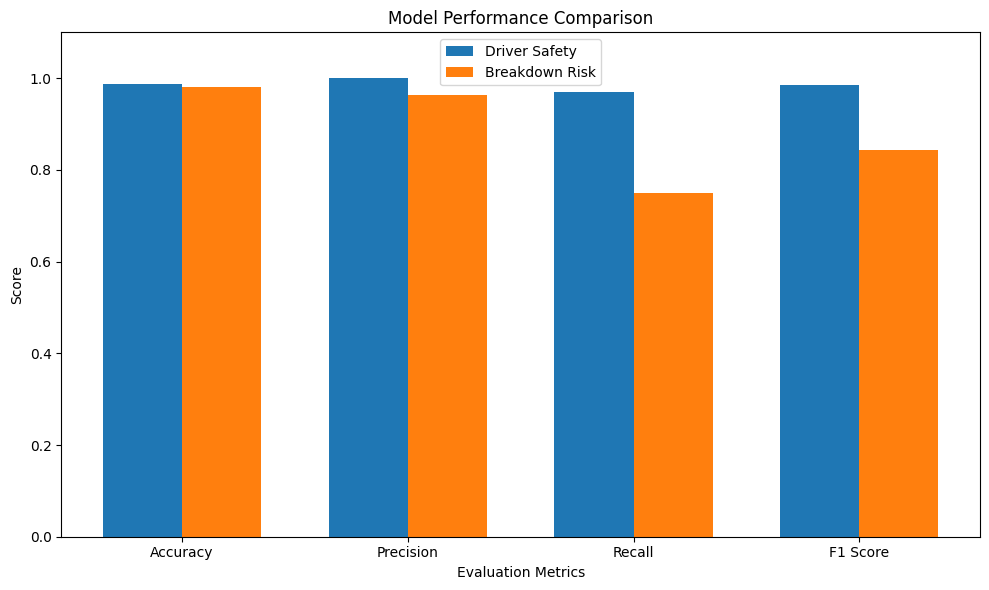

In [12]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

driver_scores = [
    driver_accuracy,
    driver_precision,
    driver_recall,
    driver_f1
]

breakdown_scores = [
    accuracy_score(y_breakdown_test, breakdown_pred),
    precision_score(y_breakdown_test, breakdown_pred),
    recall_score(y_breakdown_test, breakdown_pred),
    f1_score(y_breakdown_test, breakdown_pred)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, driver_scores, width, label="Driver Safety")
plt.bar(x + width/2, breakdown_scores, width, label="Breakdown Risk")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.1)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Driver Safety - High Risk Analysis
driver_high_risk_total = sum(y_driver_test == 1)
driver_high_risk_detected = sum((y_driver_test == 1) & (driver_pred == 1))
driver_high_risk_missed = sum((y_driver_test == 1) & (driver_pred == 0))

# Breakdown - High Risk Analysis
breakdown_high_risk_total = sum(y_breakdown_test == 1)
breakdown_high_risk_detected = sum((y_breakdown_test == 1) & (breakdown_pred == 1))
breakdown_high_risk_missed = sum((y_breakdown_test == 1) & (breakdown_pred == 0))

print("High-Risk Detection Analysis")
print("----------------------------")

print("\nDriver Safety:")
print("Total High-Risk Cases     :", driver_high_risk_total)
print("Correctly Detected        :", driver_high_risk_detected)
print("Missed High-Risk Cases    :", driver_high_risk_missed)
print("High-Risk Recall          :", round(driver_recall, 4))

print("\nBreakdown Risk:")
print("Total High-Risk Cases     :", breakdown_high_risk_total)
print("Correctly Detected        :", breakdown_high_risk_detected)
print("Missed High-Risk Cases    :", breakdown_high_risk_missed)
print("High-Risk Recall          :", round(
    recall_score(y_breakdown_test, breakdown_pred), 4
))

High-Risk Detection Analysis
----------------------------

Driver Safety:
Total High-Risk Cases     : 404
Correctly Detected        : 392
Missed High-Risk Cases    : 12
High-Risk Recall          : 0.9703

Breakdown Risk:
Total High-Risk Cases     : 72
Correctly Detected        : 54
Missed High-Risk Cases    : 18
High-Risk Recall          : 0.75


In [14]:
print(" FINAL MODEL EVALUATION")

print("\nDriver Safety Model")
print("\n")
print(f"Accuracy       : {driver_accuracy:.4f}")
print(f"Precision      : {driver_precision:.4f}")
print(f"Recall         : {driver_recall:.4f}")
print(f"F1 Score       : {driver_f1:.4f}")
print(f"High-Risk Miss : {driver_high_risk_missed}")

breakdown_accuracy = accuracy_score(y_breakdown_test, breakdown_pred)
breakdown_precision = precision_score(y_breakdown_test, breakdown_pred)
breakdown_recall = recall_score(y_breakdown_test, breakdown_pred)
breakdown_f1 = f1_score(y_breakdown_test, breakdown_pred)

print("\nBreakdown Risk Model")
print("\n")
print(f"Accuracy       : {breakdown_accuracy:.4f}")
print(f"Precision      : {breakdown_precision:.4f}")
print(f"Recall         : {breakdown_recall:.4f}")
print(f"F1 Score       : {breakdown_f1:.4f}")
print(f"High-Risk Miss : {breakdown_high_risk_missed}")



 FINAL MODEL EVALUATION

Driver Safety Model


Accuracy       : 0.9880
Precision      : 1.0000
Recall         : 0.9703
F1 Score       : 0.9849
High-Risk Miss : 12

Breakdown Risk Model


Accuracy       : 0.9800
Precision      : 0.9643
Recall         : 0.7500
F1 Score       : 0.8438
High-Risk Miss : 18
